# standard pre-processing of all cells

In [6]:
library(Seurat)
library(dplyr)
library(patchwork)

In [7]:
# setup the seurat object
vsx1.data <- Read10X(data.dir = "./vsx1_matrix/")
vsx1 <- CreateSeuratObject(counts = vsx1.data, project = "spinal_vsx1")
vsx1

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


An object of class Seurat 
27597 features across 11000 samples within 1 assay 
Active assay: RNA (27597 features, 0 variable features)
 1 layer present: counts

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


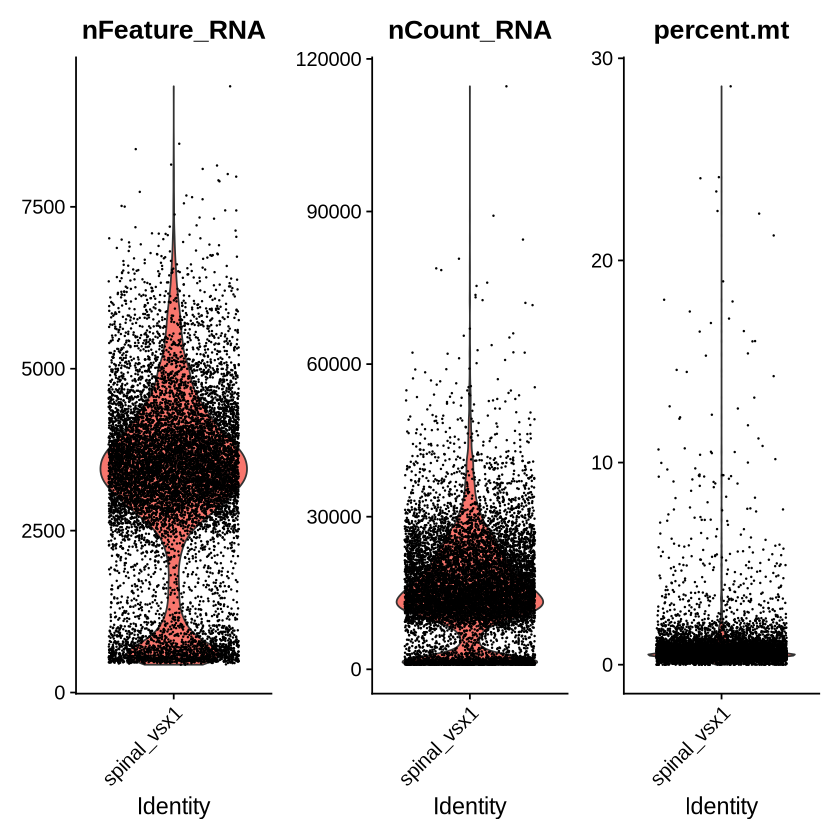

In [8]:
# QC
vsx1[["percent.mt"]] <- PercentageFeatureSet(vsx1, pattern = "^mt-")
VlnPlot(vsx1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

An object of class Seurat 
27597 features across 8956 samples within 1 assay 
Active assay: RNA (27597 features, 0 variable features)
 1 layer present: counts

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


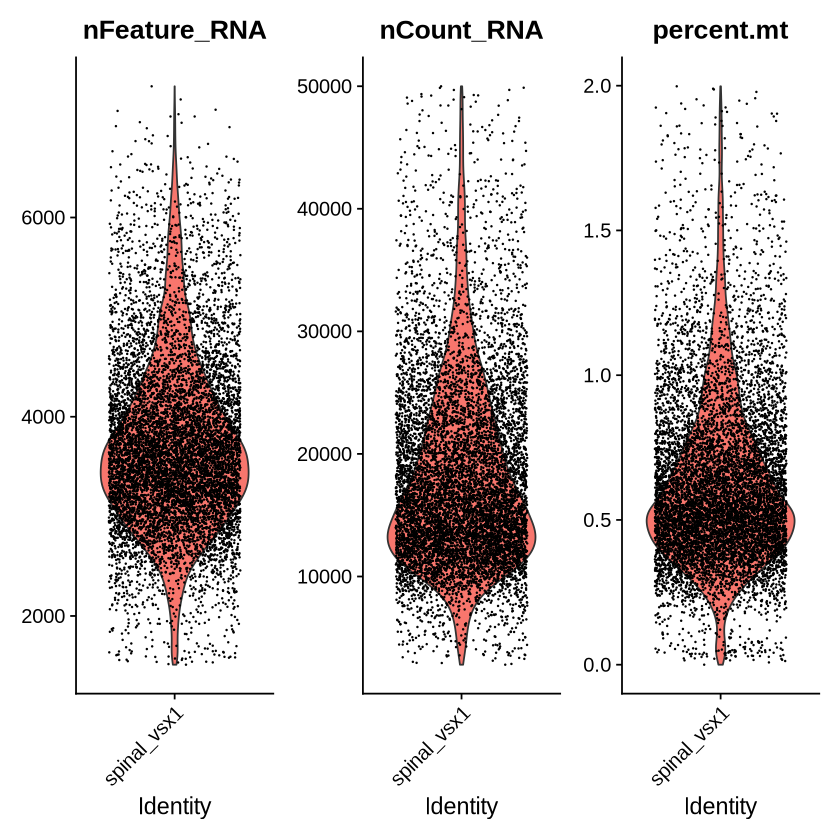

In [9]:
vsx1 <- subset(vsx1, subset = nFeature_RNA > 1500 & nFeature_RNA < 7500)
vsx1 <- subset(vsx1, subset = nCount_RNA > 100 & nCount_RNA < 50000 & percent.mt < 2)
vsx1
VlnPlot(vsx1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  hsp90aa1.1, ttn.1, efemp2a, unc45b, atp5mc3b, emp2, actc1a, zgc:92429, smyd1b, pbxip1b 
	   nexn, ttn.2, pdlim7, acta1a, rbm24a, tnni2b.1, txlnba, mybphb, ldb3a, klhl41b 
	   chchd10, actc1b, hspb8, tpma, bin1b, c1qbp, musk, tspan9a, apobec2a, actn3b 
Negative:  ptmab, ptmaa, tmsb4x, nova2, tuba1c, calm2b, si:dkey-276j7.1, tmeff1b, tuba1a, rtn1a 
	   hsp90aa1.2, si:ch211-222l21.1, stx1b, stmn1b, rnasekb, sncb, ank2b, gng2, elavl3, stxbp1a 
	   si:dkey-280e21.3, calm2a, tubb2b, gapdhs, myt1a, zgc:153426, hsp90ab1, gnao1a, si:ch73-1a9.3, calm1a 
PC_ 2 
Positive:  hmgb2b, si:ch73-281n10.2, anp32b, cx43.4, hmgb2a, sumo3b, stmn1a, pcna, chaf1a, seta 
	   banf1, ranbp1, hmga1a, dut, ccnd1, anp32a, tuba8l4, mdka, nasp, yap1 
	   rrm1, rpa2, rpa3, dek, her12, hmgn2, pclaf, id1, zbtb16a, lig1 
Negative:  ywhag2, hk1, eno1a, tpi1b, cpeb4b, pcbp4, calm3a.1, ank2a, casz1, pha

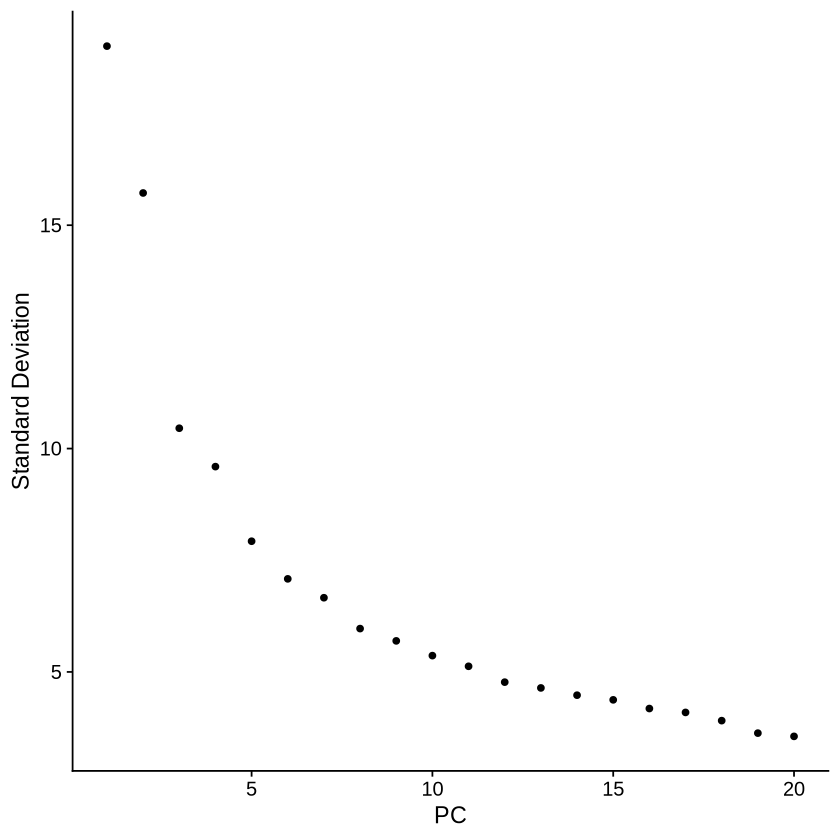

In [10]:
# normalize the date
vsx1 <- NormalizeData(vsx1, normalization.method = "LogNormalize", scale.factor = 10000)
# select variable features
vsx1 <- FindVariableFeatures(vsx1, selection.method = "vst", nfeatures = 4000)
# scale the data
vsx1 <- ScaleData(object = vsx1)
# linear dimensional reduction
vsx1 <- RunPCA(vsx1, features = VariableFeatures(object = vsx1))
#determine the dimensionality of the dataset
vsx1 <- JackStraw(vsx1, num.replicate = 50)
vsx1 <- ScoreJackStraw(vsx1, dims = 1:20)
ElbowPlot(vsx1)

In [11]:
#cluster the cells
vsx1 <- FindNeighbors(vsx1, dims = 1:15)
vsx1 <- FindClusters(vsx1, resolution = 0.5)
# run umap
vsx1 <- RunUMAP(vsx1, dims = 1:15)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 8956
Number of edges: 257458

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9338
Number of communities: 20
Elapsed time: 0 seconds


Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
10:22:55 UMAP embedding parameters a = 0.9922 b = 1.112

10:22:55 Read 8956 rows and found 15 numeric columns

10:22:55 Using Annoy for neighbor search, n_neighbors = 30

10:22:55 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:22:57 Writing NN index file to temp file /tmp/Rtmpy38IzA/file6d9a6619f3096

10:22:57 Searching Annoy index using 1 thread, search_k = 3000

10:22:59 Annoy recall = 100%

10:23:00 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors 

## replication of Figure S4A

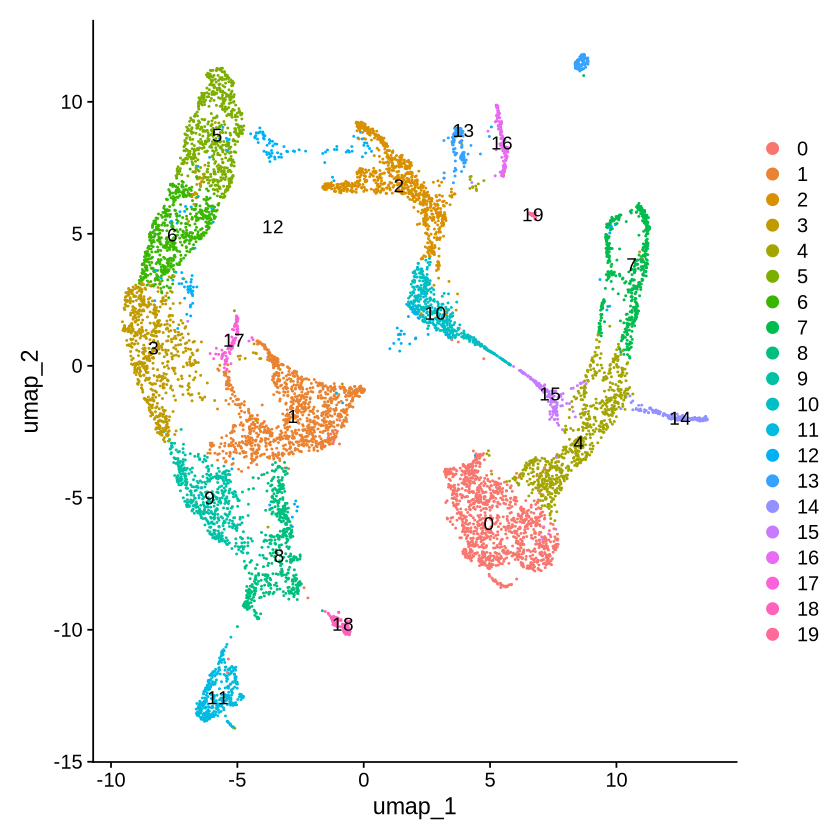

In [12]:
#visualize the clusters, replication of Figure S4A
DimPlot(vsx1, reduction = "umap", label = TRUE)

## replication of Figure S4B

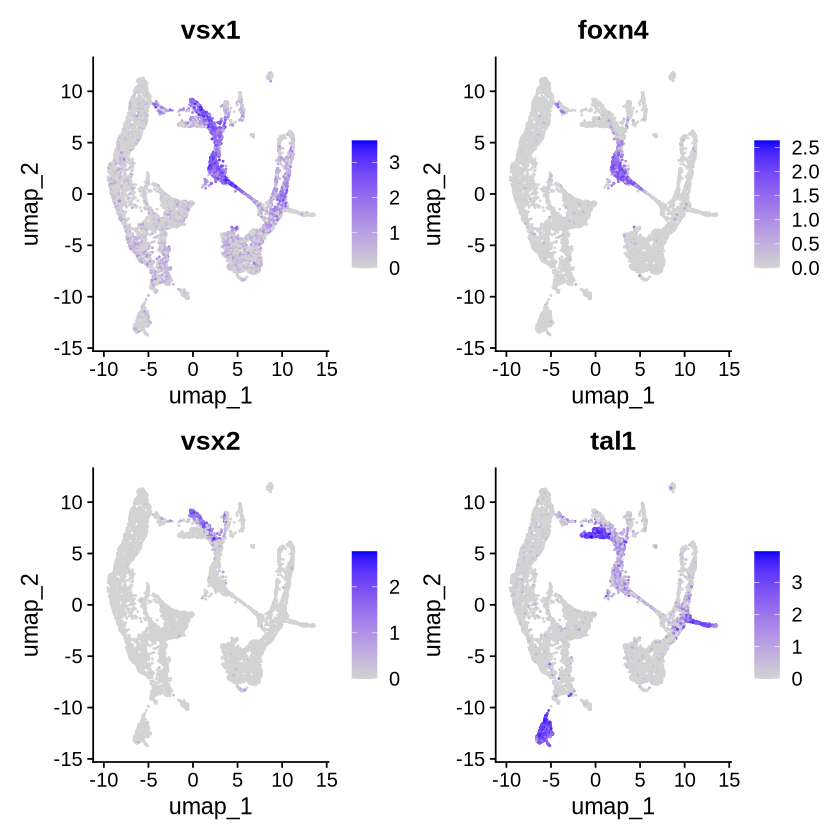

In [13]:
# visualize maker genes expression, replication of Figure S4B
FeaturePlot(vsx1, features = c("vsx1", "foxn4", "vsx2", "tal1"))

# reanalyze v2a-v2b lineage cells

In [14]:
# extract v2a-v2b lineage cells
v2av2b_raw <- subset(vsx1, idents = c( "2", "10"))
v2av2b_raw

An object of class Seurat 
27597 features across 1268 samples within 1 assay 
Active assay: RNA (27597 features, 4000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [15]:
# preprocessing
v2av2b_raw <- NormalizeData(v2av2b_raw)
v2av2b_raw <- FindVariableFeatures(v2av2b_raw, selection.method = "vst", nfeatures = 4000)
v2av2b_raw <- ScaleData(v2av2b_raw)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
"Different features in new layer data than already exists for scale.data"


PC_ 1 
Positive:  snap25a, gng3, gap43, stxbp1a, cotl1, cplx2l, stmn2b, gabbr2, pcsk1nl, vsnl1a 
	   gria3b, ywhag2, nrxn3b, rbfox3a, gapdhs, ckbb, dscama, map1aa, aplp1, hoxb6b 
	   nell2b, IGLON5, csmd2, fez1, si:dkey-280e21.3, chrnb4, id4, celf4, slc8a2b, nlgn2a 
Negative:  rrm2.1, ccna2, dek, CABZ01058261.1, mki67, stmn1a, im:7152348, rrm1, tuba8l4, lbr 
	   rpa2, smc2, foxn4, insm1a, mad2l1, tpx2, banf1, cx43.4, dut, hes6 
	   aurkb, cks1b, pcna, plk1, nusap1, top2a, smc4, cdk1, anp32b, selenoh 
PC_ 2 
Positive:  mcm6, mcm2, sb:cb81, mcm5, rhbdl3, notch3, her2, tcf12, msh6, yap1 
	   mcm3, mcm4, pcdh18b, ccndx, smad3a, uhrf1, mdka, zgc:110540, ccne2, col28a2a 
	   ctnna2, ldlrad2, zgc:113625, her12, pola1, dab2ipb, fstl1a, zbtb16a, id1, nutf2l 
Negative:  hmgn2, ube2c, h3f3a, hmgb2a, si:ch211-222l21.1, dynll1, tubb2b, birc5a, tuba1b, hmgb2b 
	   si:ch73-281n10.2, meis2a, sox14, tubb4b, stap2a, tuba1a, elavl4, calm2b, seta, slc38a3a 
	   pttg1, gata2a, golga7ba, bhlhe22, ebf2, hmmr

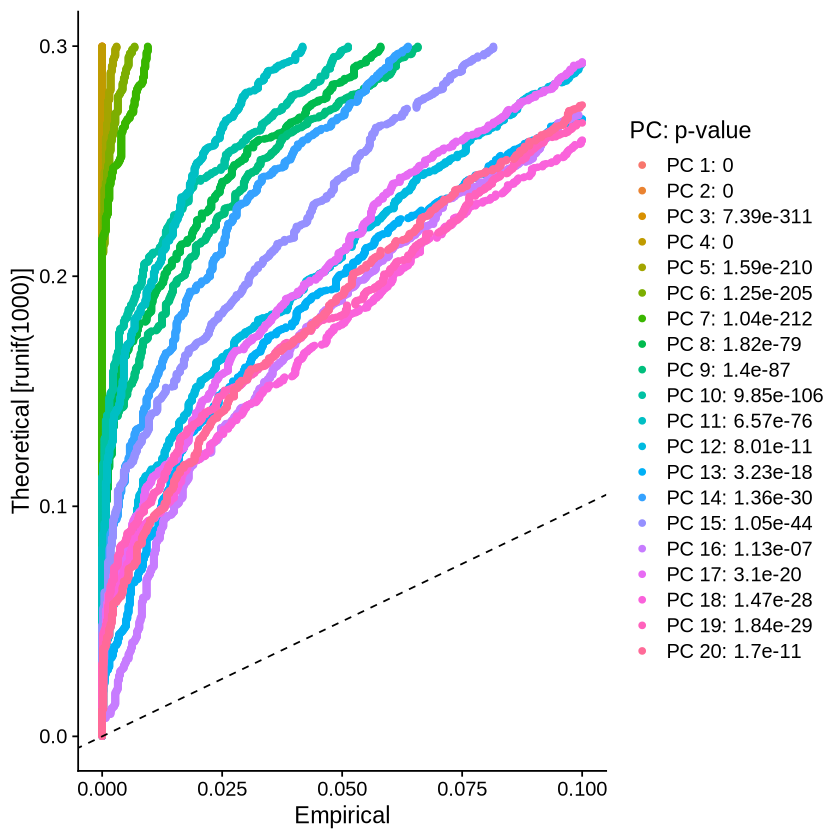

In [16]:
# dimentional reduction
v2av2b_raw <- RunPCA(v2av2b_raw, features = VariableFeatures(object = v2av2b_raw))
v2av2b_raw <- JackStraw(v2av2b_raw, num.replicate = 100)
v2av2b_raw <- ScoreJackStraw(v2av2b_raw, dims = 1:20)
JackStrawPlot(v2av2b_raw, dims = 1:20)

In [17]:
# cluster cells
v2av2b_raw <- FindNeighbors(v2av2b_raw, dims = 1:10)
v2av2b_raw <- FindClusters(v2av2b_raw, resolution = 0.6)
v2av2b_raw <- RunUMAP(v2av2b_raw, dims = 1:10)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1268
Number of edges: 35485

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8318
Number of communities: 8
Elapsed time: 0 seconds


10:25:34 UMAP embedding parameters a = 0.9922 b = 1.112

10:25:34 Read 1268 rows and found 10 numeric columns

10:25:34 Using Annoy for neighbor search, n_neighbors = 30

10:25:34 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:25:35 Writing NN index file to temp file /tmp/Rtmpy38IzA/file6d9a65e824edb

10:25:35 Searching Annoy index using 1 thread, search_k = 3000

10:25:35 Annoy recall = 100%

10:25:35 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:25:36 Initializing from normalized Laplacian + noise (using RSpectra)

10:25:36 Commencing optimization for 500 epochs, with 45698 positive edges

10:25:40 Optimization finished



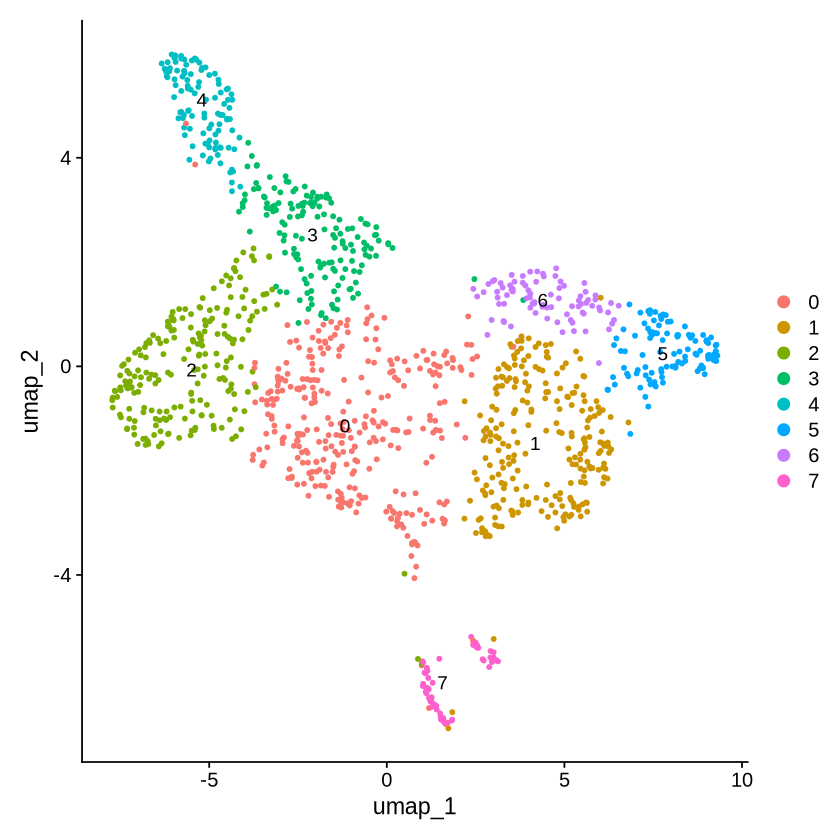

In [18]:
# visualization
DimPlot(v2av2b_raw, reduction = "umap", label = TRUE)

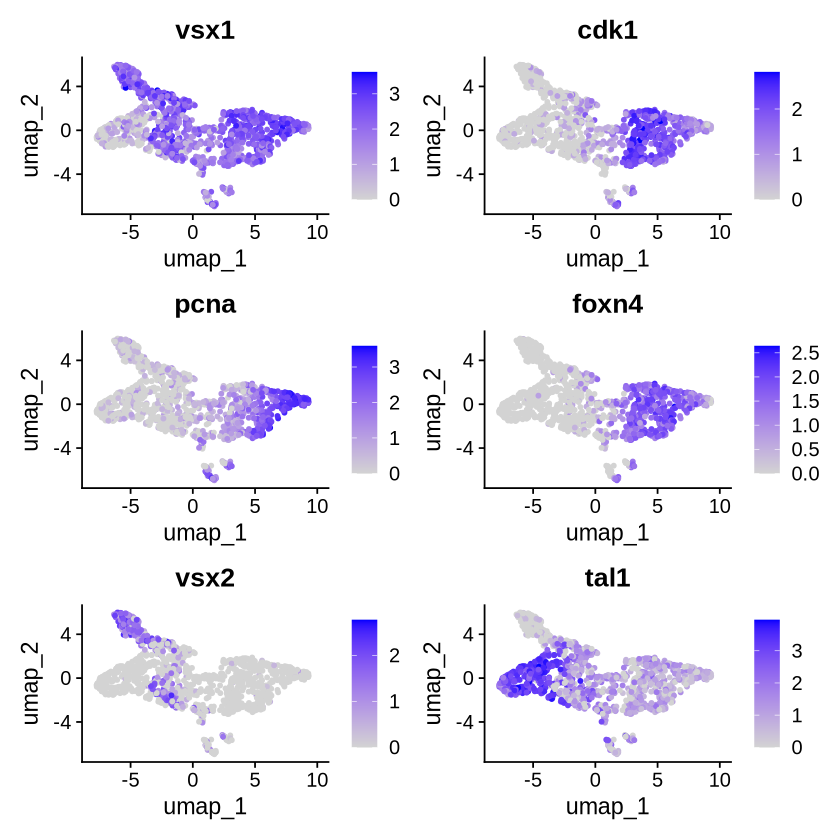

In [19]:
# check cell marker expression
FeaturePlot(v2av2b_raw, features = c("vsx1", "cdk1", "pcna", "foxn4", "vsx2", "tal1"))

## Replication of Figure S4C

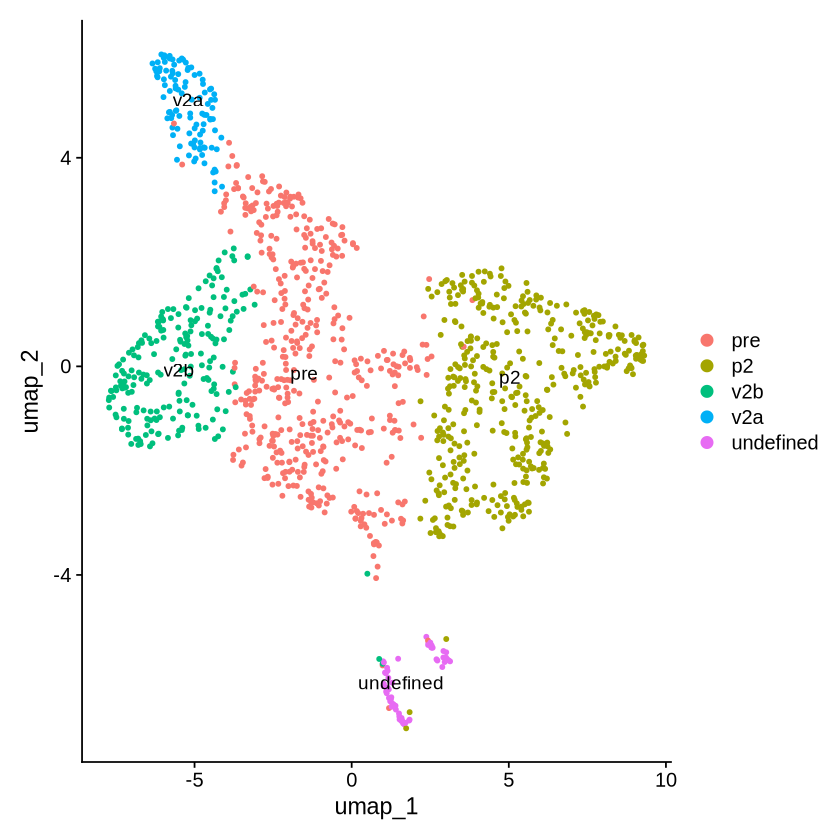

In [20]:
# annotate cell clusters. Replication of Figure S4C
new.cluster.ids <- c("pre", "p2", "v2b", "pre", "v2a", "p2", "p2", "undefined" )
names(new.cluster.ids) <- levels(v2av2b_raw)
v2av2b_raw <- RenameIdents(v2av2b_raw, new.cluster.ids)
DimPlot(v2av2b_raw, reduction = "umap", label=T)

Calculating cluster pre



For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster p2

Calculating cluster v2b

Calculating cluster v2a

Calculating cluster undefined

Warning message in DoHeatmap(v2av2b_raw, features = top10$gene):
"The following features were omitted as they were not found in the scale.data slot for the RNA assay: CSRNP3, CU571064.1"


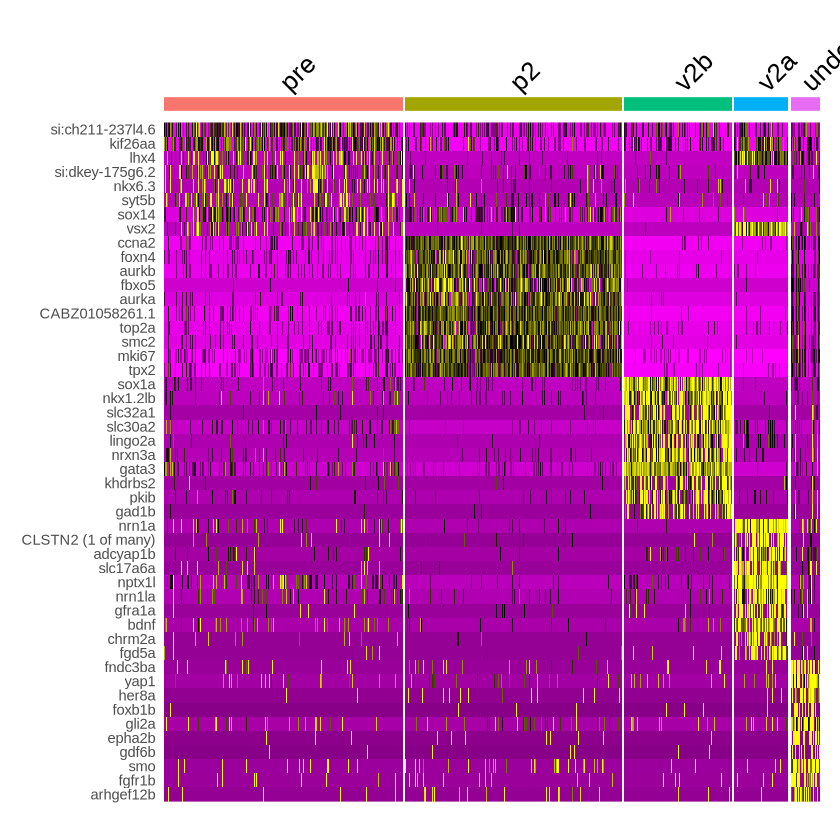

In [22]:
# find marker genes of different clusters
v2av2b_markers <- FindAllMarkers(v2av2b_raw, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)
v2av2b_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10
DoHeatmap(v2av2b_raw, features = top10$gene) + NoLegend()



## replication of Figure S4D

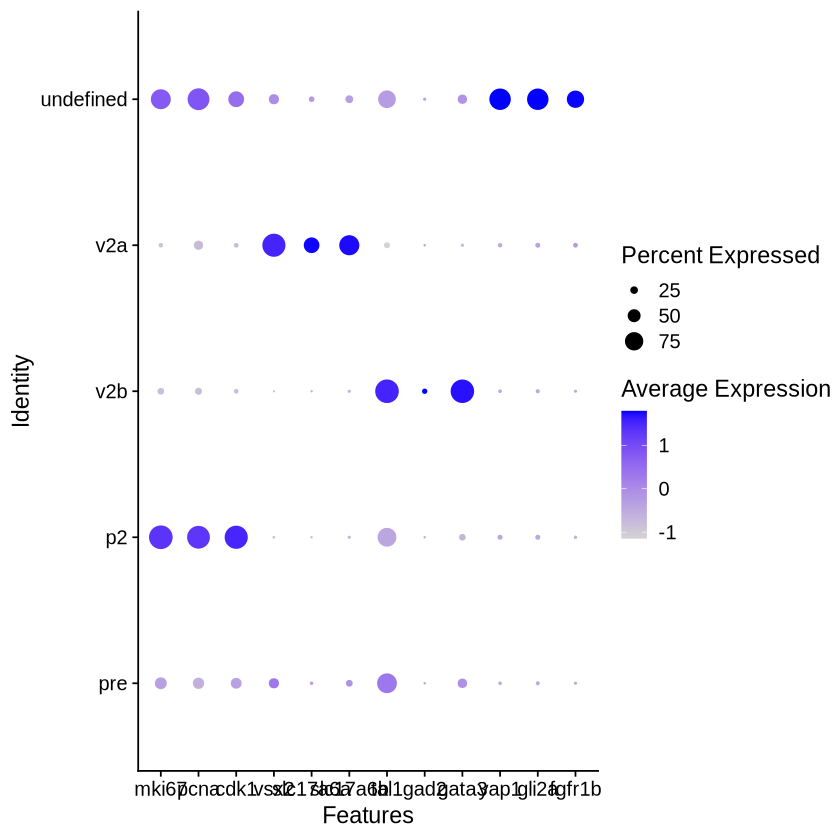

In [23]:
# expression of cell marker genes, replication of Figure S4D
DotPlot(v2av2b_raw, features = c("mki67", "pcna", "cdk1", "vsx2", "slc17a6a", "slc17a6b", "tal1", "gad2", "gata3", "yap1", "gli2a", "fgfr1b"))

In [24]:
saveRDS( v2av2b_raw, file = "/home/wangmei/NGS/scRNA/10x/spinal_vsx1_batch2/v2av2b_rna.rds")
#v2av2b <- readRDS( file = "/home/wangmei/NGS/scRNA/10x/spinal_vsx1_batch2/v2av2b_rna.rds")

# dynamics of notch genes in v2a-v2b lineage progression

## replication of Figure 3A

Warning message:
"Scaling data with a low number of groups may produce misleading results"


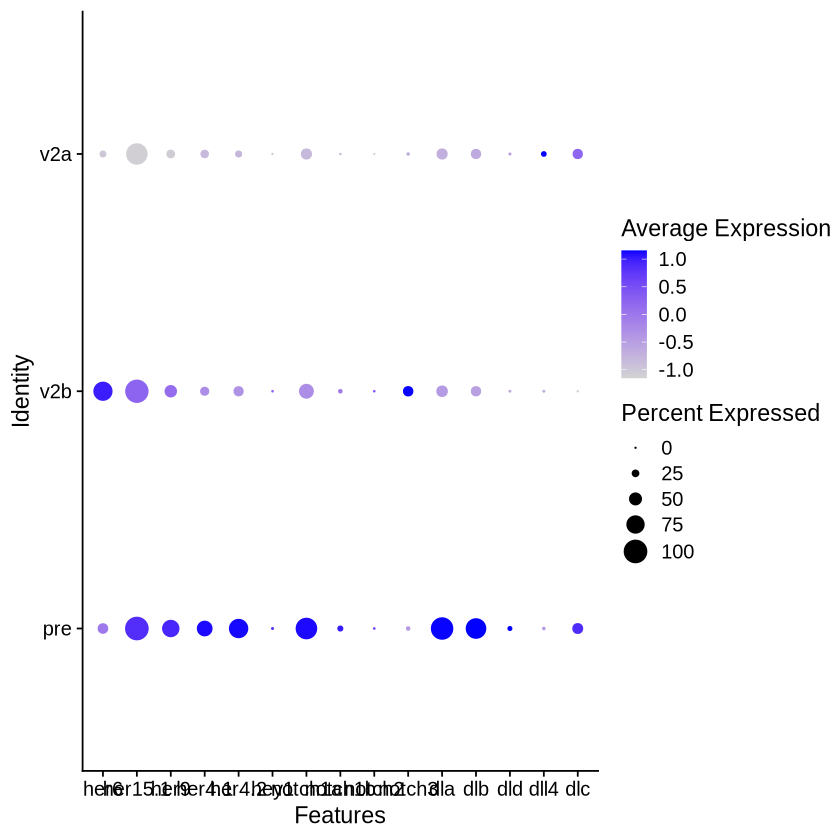

In [25]:
# dynamics of notch genes in v2a-v2b lineages, replication of Figure 3A
desired_cells <- subset(v2av2b_raw, idents = c( "v2a", "v2b", "pre"))
notch.genes <- c( "her6", "her15.1", "her9", "her4.1", "her4.2", "hey1", "notch1a", "notch1b", "notch2", "notch3",  "dla", "dlb",  "dld",  "dll4", "dlc")
DotPlot(desired_cells, features = notch.genes)

## check average expression

In [26]:
# check average expression
norm.expr <- AverageExpression(desired_cells, features = notch.genes)$RNA
head(norm.expr)



As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


6 x 3 sparse Matrix of class "dgCMatrix"
               pre        v2b        v2a
dlb     3.86090329 0.56848273 0.44206278
notch1b 0.21290358 0.10717974 0.01929055
notch3  0.10307090 0.58823436 0.03920403
her6    1.46842797 4.33621424 0.19216106
dla     7.16499545 1.24999249 0.83257893
dll4    0.06174443 0.05072347 0.16053248

In [27]:
norm.expr <- cbind(norm.expr, norm.expr[,3] / (norm.expr[,2]+0.05))
norm.expr <- norm.expr[order(norm.expr[,4], decreasing = TRUE),]
norm.expr

15 x 4 sparse Matrix of class "dgCMatrix"
                pre          v2b         v2a           
dlc      0.54400999  0.007333336 0.338216608 5.89912657
dll4     0.06174443  0.050723465 0.160532482 1.59379427
dlb      3.86090329  0.568482733 0.442062778 0.71475363
dla      7.16499545  1.249992490 0.832578929 0.64044903
notch1a  3.10778730  0.972291849 0.486378033 0.47577219
her9     1.27777361  0.896663981 0.439808549 0.46458781
her15.1 25.07337748 16.860095359 6.874467815 0.40653040
her4.2   4.66199828  0.917364436 0.382304332 0.39520197
her4.1   2.53821416  0.686514770 0.259366704 0.35215411
dld      0.11043485  0.021360551 0.024649326 0.34541950
notch1b  0.21290358  0.107179741 0.019290545 0.12272921
notch3   0.10307090  0.588234358 0.039204035 0.06142577
her6     1.46842797  4.336214243 0.192161062 0.04381023
hey1     0.02663035  0.019443125 0.002968332 0.04274480
notch2   0.01300609  0.011793250 .           .         

# enviroment

In [28]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/wangmei/anaconda3/envs/seurat5/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] patchwork_1.3.0    dplyr_1.1.4        Seurat_5.1.0       SeuratObject_5.0.2
[5] sp_2.1-4          

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-2          gridExtra_2.3         
  [4] rlang_1.1.4            magrittr_2.0.3         RcppAnnoy_0.0.22      
  [7] spatstat.geom_3.2-9    matrixStats_1.4.1      ggridges_0.5.6        
 [10] compiler_4.3.3         png_0.1-8              vctrs_0.6.5           
 [13] reshape2_1.4.4         stringr_1.5.1          pkgconfig_2.0.3       
 [16] crayon_1.5.3           fastmap_1.2.0    

In [31]:
sessioninfo::session_info(to_file = "session_v2av2b_rna.md")